# Trade Anomaly Detection System
## Comprehensive Analysis Including Cancel Patterns

This notebook demonstrates advanced trade anomaly detection techniques including:
- Volume spike detection
- Price manipulation identification
- Cancellation abuse patterns
- Wash trading detection
- Timing anomaly analysis

### Requirements
Make sure you have the following packages installed:
```bash
pip install pandas numpy scipy matplotlib seaborn
```

In [46]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy import stats
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📦 Libraries imported successfully!")

📦 Libraries imported successfully!


## Step 1: Define the Trade Anomaly Detection Class

This class contains all the detection methods and provides a comprehensive framework for identifying suspicious trading patterns.

In [47]:
class TradeAnomalyDetector:
    """
    Advanced trade anomaly detection system that identifies suspicious trading patterns
    including cancellation behaviors, wash trading, and market manipulation indicators.
    """
    
    def __init__(self, z_threshold=2.5, volume_multiplier=3.0, cancel_ratio_threshold=0.8):
        """
        Initialize the anomaly detector with configurable thresholds.
        
        Parameters:
        - z_threshold: Standard deviations for statistical anomaly detection
        - volume_multiplier: How many times normal volume to flag as anomaly
        - cancel_ratio_threshold: Ratio of cancels to orders to flag suspicious behavior
        """
        self.z_threshold = z_threshold
        self.volume_multiplier = volume_multiplier
        self.cancel_ratio_threshold = cancel_ratio_threshold
        self.anomalies = []
        
    def load_sample_data(self):
        """
        Generate realistic sample trading data for demonstration.
        Creates orders, trades, and cancellations with some anomalous patterns.
        """
        np.random.seed(42)  # For reproducible results
        
        # Generate base trading data
        n_records = 1000
        base_time = datetime.now() - timedelta(days=1)
        
        # Create realistic trading data with some anomalies injected
        data = []
        
        for i in range(n_records):
            timestamp = base_time + timedelta(minutes=i)
            
            # Normal trading pattern with some anomalies
            if i % 100 == 0:  # Every 100th record is potentially anomalous
                # High volume anomaly
                volume = np.random.normal(10000, 2000)
                price = np.random.normal(100, 20)  # Wider price spread
                order_type = np.random.choice(['BUY', 'SELL'])
                action = np.random.choice(['TRADE', 'CANCEL'], p=[0.3, 0.7])  # High cancel ratio
            elif i % 50 == 0:  # Price manipulation pattern
                volume = np.random.normal(500, 100)
                price = 100 + np.sin(i/10) * 10  # Artificial price pattern
                order_type = 'BUY' if np.sin(i/10) > 0 else 'SELL'
                action = np.random.choice(['TRADE', 'ORDER', 'CANCEL'], p=[0.6, 0.2, 0.2])
            else:  # Normal trading
                volume = np.random.normal(1000, 200)
                price = np.random.normal(100, 2)
                order_type = np.random.choice(['BUY', 'SELL'])
                action = np.random.choice(['TRADE', 'ORDER', 'CANCEL'], p=[0.7, 0.2, 0.1])
            
            data.append({
                'timestamp': timestamp,
                'trader_id': f'T{np.random.randint(1, 50):03d}',
                'symbol': np.random.choice(['AAPL', 'GOOGL', 'MSFT', 'TSLA'], p=[0.4, 0.3, 0.2, 0.1]),
                'action': action,
                'order_type': order_type,
                'price': max(1, price),  # Ensure positive price
                'volume': max(1, int(volume)),  # Ensure positive volume
                'order_id': f'ORD_{i:06d}'
            })
        
        return pd.DataFrame(data)
    
    def detect_volume_anomalies(self, df):
        """
        Detect volume-based anomalies using statistical methods.
        Identifies trades with unusually high or low volumes compared to historical patterns.
        """
        print("🔍 Detecting volume anomalies...")
        
        volume_anomalies = []
        
        # Group by symbol to detect anomalies per instrument
        for symbol in df['symbol'].unique():
            symbol_data = df[df['symbol'] == symbol].copy()
            
            # Calculate volume statistics for trades only
            trade_data = symbol_data[symbol_data['action'] == 'TRADE']
            if len(trade_data) < 10:  # Need minimum data points
                continue
                
            mean_volume = trade_data['volume'].mean()
            std_volume = trade_data['volume'].std()
            
            # Z-score based anomaly detection
            trade_data['volume_zscore'] = np.abs((trade_data['volume'] - mean_volume) / std_volume)
            
            # Flag high volume anomalies
            high_volume_anomalies = trade_data[
                (trade_data['volume_zscore'] > self.z_threshold) | 
                (trade_data['volume'] > mean_volume * self.volume_multiplier)
            ]
            
            for _, row in high_volume_anomalies.iterrows():
                volume_anomalies.append({
                    'type': 'VOLUME_ANOMALY',
                    'timestamp': row['timestamp'],
                    'trader_id': row['trader_id'],
                    'symbol': row['symbol'],
                    'details': f"Volume {row['volume']:,.0f} vs avg {mean_volume:,.0f} (Z-score: {row['volume_zscore']:.2f})",
                    'severity': 'HIGH' if row['volume_zscore'] > self.z_threshold * 1.5 else 'MEDIUM'
                })
        
        print(f"   Found {len(volume_anomalies)} volume anomalies")
        return volume_anomalies
    
    def detect_price_anomalies(self, df):
        """
        Detect price-based anomalies and potential manipulation.
        Identifies sudden price movements, outliers, and suspicious pricing patterns.
        """
        print("💰 Detecting price anomalies...")
        
        price_anomalies = []
        
        for symbol in df['symbol'].unique():
            symbol_data = df[df['symbol'] == symbol].copy()
            trade_data = symbol_data[symbol_data['action'] == 'TRADE'].sort_values('timestamp')
            
            if len(trade_data) < 5:
                continue
            
            # Calculate price changes and volatility
            trade_data['price_change'] = trade_data['price'].pct_change()
            trade_data['price_ma'] = trade_data['price'].rolling(window=10, min_periods=1).mean()
            trade_data['price_deviation'] = abs(trade_data['price'] - trade_data['price_ma']) / trade_data['price_ma']
            
            # Detect sudden price spikes
            price_change_threshold = trade_data['price_change'].std() * 3
            price_spikes = trade_data[
                abs(trade_data['price_change']) > price_change_threshold
            ]
            
            # Detect prices far from moving average
            deviation_threshold = 0.05  # 5% deviation from moving average
            price_outliers = trade_data[
                trade_data['price_deviation'] > deviation_threshold
            ]
            
            # Combine all price anomalies
            all_price_anomalies = pd.concat([price_spikes, price_outliers]).drop_duplicates()
            
            for _, row in all_price_anomalies.iterrows():
                price_anomalies.append({
                    'type': 'PRICE_ANOMALY',
                    'timestamp': row['timestamp'],
                    'trader_id': row['trader_id'],
                    'symbol': row['symbol'],
                    'details': f"Price ${row['price']:.2f}, change: {row['price_change']*100:.1f}%, deviation: {row['price_deviation']*100:.1f}%",
                    'severity': 'HIGH' if abs(row['price_change']) > price_change_threshold * 2 else 'MEDIUM'
                })
        
        print(f"   Found {len(price_anomalies)} price anomalies")
        return price_anomalies
    
    def detect_cancel_anomalies(self, df):
        """
        Detect cancellation-based anomalies and suspicious order patterns.
        Identifies high cancel ratios, rapid cancel patterns, and potential quote stuffing.
        """
        print("❌ Detecting cancellation anomalies...")
        
        cancel_anomalies = []
        
        # Analyze cancellation patterns by trader
        for trader_id in df['trader_id'].unique():
            trader_data = df[df['trader_id'] == trader_id]
            
            total_orders = len(trader_data[trader_data['action'].isin(['ORDER', 'CANCEL'])])
            total_cancels = len(trader_data[trader_data['action'] == 'CANCEL'])
            
            if total_orders == 0:
                continue
                
            cancel_ratio = total_cancels / total_orders
            
            # Flag high cancel ratios
            if cancel_ratio > self.cancel_ratio_threshold:
                cancel_anomalies.append({
                    'type': 'HIGH_CANCEL_RATIO',
                    'timestamp': trader_data['timestamp'].max(),
                    'trader_id': trader_id,
                    'symbol': 'MULTIPLE',
                    'details': f"Cancel ratio: {cancel_ratio:.1%} ({total_cancels}/{total_orders})",
                    'severity': 'HIGH' if cancel_ratio > 0.9 else 'MEDIUM'
                })
        
        # Detect rapid cancel patterns (potential quote stuffing)
        df_sorted = df.sort_values('timestamp')
        for symbol in df['symbol'].unique():
            symbol_data = df_sorted[df_sorted['symbol'] == symbol]
            
            # Look for rapid order-cancel sequences
            for i in range(len(symbol_data) - 5):
                window = symbol_data.iloc[i:i+5]
                
                # Check if there are multiple cancels in a short time window
                time_window = (window['timestamp'].max() - window['timestamp'].min()).total_seconds()
                cancel_count = len(window[window['action'] == 'CANCEL'])
                
                if time_window < 60 and cancel_count >= 3:  # 3+ cancels within 1 minute
                    trader_ids = window['trader_id'].unique()
                    for trader_id in trader_ids:
                        trader_cancels = len(window[(window['trader_id'] == trader_id) & (window['action'] == 'CANCEL')])
                        if trader_cancels >= 2:
                            cancel_anomalies.append({
                                'type': 'RAPID_CANCEL_PATTERN',
                                'timestamp': window['timestamp'].iloc[-1],
                                'trader_id': trader_id,
                                'symbol': symbol,
                                'details': f"Rapid cancels: {trader_cancels} in {time_window:.0f}s",
                                'severity': 'HIGH'
                            })
        
        print(f"   Found {len(cancel_anomalies)} cancellation anomalies")
        return cancel_anomalies
    
    def detect_wash_trading(self, df):
        """
        Detect potential wash trading patterns.
        Identifies traders who frequently trade with themselves or in suspicious patterns.
        """
        print("🔄 Detecting wash trading patterns...")
        
        wash_trading_anomalies = []
        
        # Group trades by symbol and time windows
        trade_data = df[df['action'] == 'TRADE'].copy()
        
        for symbol in trade_data['symbol'].unique():
            symbol_trades = trade_data[trade_data['symbol'] == symbol].sort_values('timestamp')
            
            # Look for back-and-forth trading patterns
            for trader_id in symbol_trades['trader_id'].unique():
                trader_trades = symbol_trades[symbol_trades['trader_id'] == trader_id]
                
                if len(trader_trades) < 4:
                    continue
                
                # Check for alternating buy/sell pattern
                order_types = trader_trades['order_type'].tolist()
                alternating_count = 0
                
                for i in range(len(order_types) - 1):
                    if order_types[i] != order_types[i + 1]:
                        alternating_count += 1
                
                alternating_ratio = alternating_count / (len(order_types) - 1) if len(order_types) > 1 else 0
                
                # Flag potential wash trading
                if alternating_ratio > 0.7 and len(trader_trades) >= 6:
                    wash_trading_anomalies.append({
                        'type': 'POTENTIAL_WASH_TRADING',
                        'timestamp': trader_trades['timestamp'].iloc[-1],
                        'trader_id': trader_id,
                        'symbol': symbol,
                        'details': f"Alternating pattern: {alternating_ratio:.1%} over {len(trader_trades)} trades",
                        'severity': 'HIGH'
                    })
        
        print(f"   Found {len(wash_trading_anomalies)} potential wash trading patterns")
        return wash_trading_anomalies
    
    def detect_timing_anomalies(self, df):
        """
        Detect timing-based anomalies.
        Identifies unusual trading times, burst patterns, and coordinated activities.
        """
        print("⏰ Detecting timing anomalies...")
        
        timing_anomalies = []
        
        # Detect burst trading (high frequency in short time windows)
        df_sorted = df.sort_values('timestamp')
        
        for trader_id in df['trader_id'].unique():
            trader_data = df_sorted[df_sorted['trader_id'] == trader_id]
            
            if len(trader_data) < 10:
                continue
            
            # Calculate time differences between consecutive actions
            trader_data = trader_data.copy()
            trader_data['time_diff'] = trader_data['timestamp'].diff().dt.total_seconds()
            
            # Find rapid trading bursts (multiple actions within seconds)
            rapid_actions = trader_data[trader_data['time_diff'] < 5]  # Less than 5 seconds apart
            
            if len(rapid_actions) > 5:  # More than 5 rapid actions
                timing_anomalies.append({
                    'type': 'BURST_TRADING',
                    'timestamp': rapid_actions['timestamp'].iloc[-1],
                    'trader_id': trader_id,
                    'symbol': 'MULTIPLE',
                    'details': f"Rapid trading: {len(rapid_actions)} actions within 5s intervals",
                    'severity': 'MEDIUM'
                })
        
        print(f"   Found {len(timing_anomalies)} timing anomalies")
        return timing_anomalies
    
    def run_detection(self, df=None):
        """
        Run complete anomaly detection pipeline.
        Orchestrates all detection methods and compiles results.
        """
        print("🚀 Starting comprehensive trade anomaly detection...")
        print("=" * 60)
        
        # Use provided data or generate sample data
        if df is None:
            print("📊 Loading sample trading data...")
            df = self.load_sample_data()
        
        print(f"📈 Analyzing {len(df):,} trading records...")
        print(f"📅 Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        print(f"👥 Traders: {df['trader_id'].nunique()}")
        print(f"💹 Symbols: {df['symbol'].nunique()}")
        print()
        
        # Clear previous results
        self.anomalies = []
        
        # Run all detection methods
        volume_anomalies = self.detect_volume_anomalies(df)
        price_anomalies = self.detect_price_anomalies(df)
        cancel_anomalies = self.detect_cancel_anomalies(df)
        wash_trading_anomalies = self.detect_wash_trading(df)
        timing_anomalies = self.detect_timing_anomalies(df)
        
        # Combine all anomalies
        self.anomalies = (volume_anomalies + price_anomalies + cancel_anomalies + 
                         wash_trading_anomalies + timing_anomalies)
        
        return self.anomalies, df
    
    def generate_report(self):
        """
        Generate comprehensive anomaly detection report.
        Creates detailed summary with statistics and recommendations.
        """
        if not self.anomalies:
            print("⚠️  No anomalies detected or detection not run yet.")
            return
        
        print("\n" + "=" * 60)
        print("📋 TRADE ANOMALY DETECTION REPORT")
        print("=" * 60)
        
        # Summary statistics
        total_anomalies = len(self.anomalies)
        anomaly_types = defaultdict(int)
        severity_counts = defaultdict(int)
        trader_anomalies = defaultdict(int)
        symbol_anomalies = defaultdict(int)
        
        for anomaly in self.anomalies:
            anomaly_types[anomaly['type']] += 1
            severity_counts[anomaly['severity']] += 1
            trader_anomalies[anomaly['trader_id']] += 1
            if anomaly['symbol'] != 'MULTIPLE':
                symbol_anomalies[anomaly['symbol']] += 1
        
        print(f"🔍 Total Anomalies Detected: {total_anomalies}")
        print(f"🚨 High Severity: {severity_counts['HIGH']}")
        print(f"⚠️  Medium Severity: {severity_counts['MEDIUM']}")
        print()
        
        # Anomaly breakdown by type
        print("📊 ANOMALY BREAKDOWN BY TYPE:")
        print("-" * 40)
        for anomaly_type, count in sorted(anomaly_types.items()):
            print(f"  {anomaly_type.replace('_', ' ').title()}: {count}")
        print()
        
        # Top problematic traders
        print("👥 TOP TRADERS WITH ANOMALIES:")
        print("-" * 40)
        top_traders = sorted(trader_anomalies.items(), key=lambda x: x[1], reverse=True)[:5]
        for trader, count in top_traders:
            print(f"  {trader}: {count} anomalies")
        print()
        
        # Top problematic symbols
        if symbol_anomalies:
            print("💹 TOP SYMBOLS WITH ANOMALIES:")
            print("-" * 40)
            top_symbols = sorted(symbol_anomalies.items(), key=lambda x: x[1], reverse=True)[:5]
            for symbol, count in top_symbols:
                print(f"  {symbol}: {count} anomalies")
            print()
        
        return {
            'total_anomalies': total_anomalies,
            'anomaly_types': dict(anomaly_types),
            'severity_counts': dict(severity_counts),
            'top_traders': dict(top_traders),
            'top_symbols': dict(top_symbols)
        }

print("✅ TradeAnomalyDetector class defined successfully!")

✅ TradeAnomalyDetector class defined successfully!


## Step 2: Initialize the Detector and Load Data

Create an instance of the detector with custom thresholds and load sample trading data.

In [48]:
# Initialize detector with custom thresholds
detector = TradeAnomalyDetector(
    z_threshold=2.0,           # Lower threshold for more sensitive detection
    volume_multiplier=2.5,     # Flag volumes 2.5x above average
    cancel_ratio_threshold=0.7  # Flag cancel ratios above 70%
)

print("🎯 Trade Anomaly Detector initialized with custom thresholds:")
print(f"   Z-Score Threshold: {detector.z_threshold}")
print(f"   Volume Multiplier: {detector.volume_multiplier}")
print(f"   Cancel Ratio Threshold: {detector.cancel_ratio_threshold:.1%}")

🎯 Trade Anomaly Detector initialized with custom thresholds:
   Z-Score Threshold: 2.0
   Volume Multiplier: 2.5
   Cancel Ratio Threshold: 70.0%


## Step 3: Run Comprehensive Anomaly Detection

Execute the complete detection pipeline to identify all types of anomalies.

In [49]:
# Run complete detection pipeline
anomalies, trading_data = detector.run_detection()

print(f"\n🎯 Detection Complete! Found {len(anomalies)} total anomalies.")

🚀 Starting comprehensive trade anomaly detection...
📊 Loading sample trading data...
📈 Analyzing 1,000 trading records...
📅 Time range: 2026-01-07 21:46:20.826959 to 2026-01-08 14:25:20.826959
👥 Traders: 49
💹 Symbols: 4

🔍 Detecting volume anomalies...
   Found 6 volume anomalies
💰 Detecting price anomalies...
   Found 22 price anomalies
❌ Detecting cancellation anomalies...
   Found 0 cancellation anomalies
🔄 Detecting wash trading patterns...
   Found 5 potential wash trading patterns
⏰ Detecting timing anomalies...
   Found 0 timing anomalies

🎯 Detection Complete! Found 33 total anomalies.


## Step 4: Analyze Trading Data

Let's examine the characteristics of our trading data and visualize patterns.

In [50]:
# Display basic statistics about the trading data
print("📊 TRADING DATA OVERVIEW")
print("=" * 40)
print(f"Total Records: {len(trading_data):,}")
print(f"Date Range: {trading_data['timestamp'].min().strftime('%Y-%m-%d %H:%M')} to {trading_data['timestamp'].max().strftime('%Y-%m-%d %H:%M')}")
print(f"Unique Traders: {trading_data['trader_id'].nunique()}")
print(f"Symbols Traded: {', '.join(trading_data['symbol'].unique())}")
print()

# Action breakdown
action_counts = trading_data['action'].value_counts()
print("📈 ACTION BREAKDOWN:")
for action, count in action_counts.items():
    percentage = (count / len(trading_data)) * 100
    print(f"  {action}: {count:,} ({percentage:.1f}%)")
print()

# Display first few records
print("📋 SAMPLE TRADING RECORDS:")
display(trading_data.head(10))

📊 TRADING DATA OVERVIEW
Total Records: 1,000
Date Range: 2026-01-07 21:46 to 2026-01-08 14:25
Unique Traders: 49
Symbols Traded: AAPL, MSFT, TSLA, GOOGL

📈 ACTION BREAKDOWN:
  TRADE: 701 (70.1%)
  ORDER: 203 (20.3%)
  CANCEL: 96 (9.6%)

📋 SAMPLE TRADING RECORDS:


,timestamp,trader_id,symbol,action,order_type,price,volume,order_id
0,2026-01-07 21:46:20.826959,T021,AAPL,CANCEL,BUY,97.234714,10993,ORD_000000
1,2026-01-07 21:47:20.826959,T002,MSFT,TRADE,SELL,102.021031,1055,ORD_000001
2,2026-01-07 21:48:20.826959,T028,TSLA,TRADE,BUY,99.144414,1004,ORD_000002
3,2026-01-07 21:49:20.826959,T003,MSFT,TRADE,SELL,99.672266,949,ORD_000003
4,2026-01-07 21:50:20.826959,T014,MSFT,CANCEL,SELL,103.825543,894,ORD_000004
5,2026-01-07 21:51:20.826959,T007,GOOGL,TRADE,SELL,99.416613,879,ORD_000005
6,2026-01-07 21:52:20.826959,T040,MSFT,TRADE,BUY,100.751129,926,ORD_000006
7,2026-01-07 21:53:20.826959,T018,MSFT,TRADE,SELL,99.293767,724,ORD_000007
8,2026-01-07 21:54:20.826959,T040,MSFT,TRADE,SELL,100.342737,1147,ORD_000008
9,2026-01-07 21:55:20.826959,T045,AAPL,TRADE,SELL,103.283542,1052,ORD_000009


## Step 5: Create Visualizations

Generate charts to better understand trading patterns and anomalies.

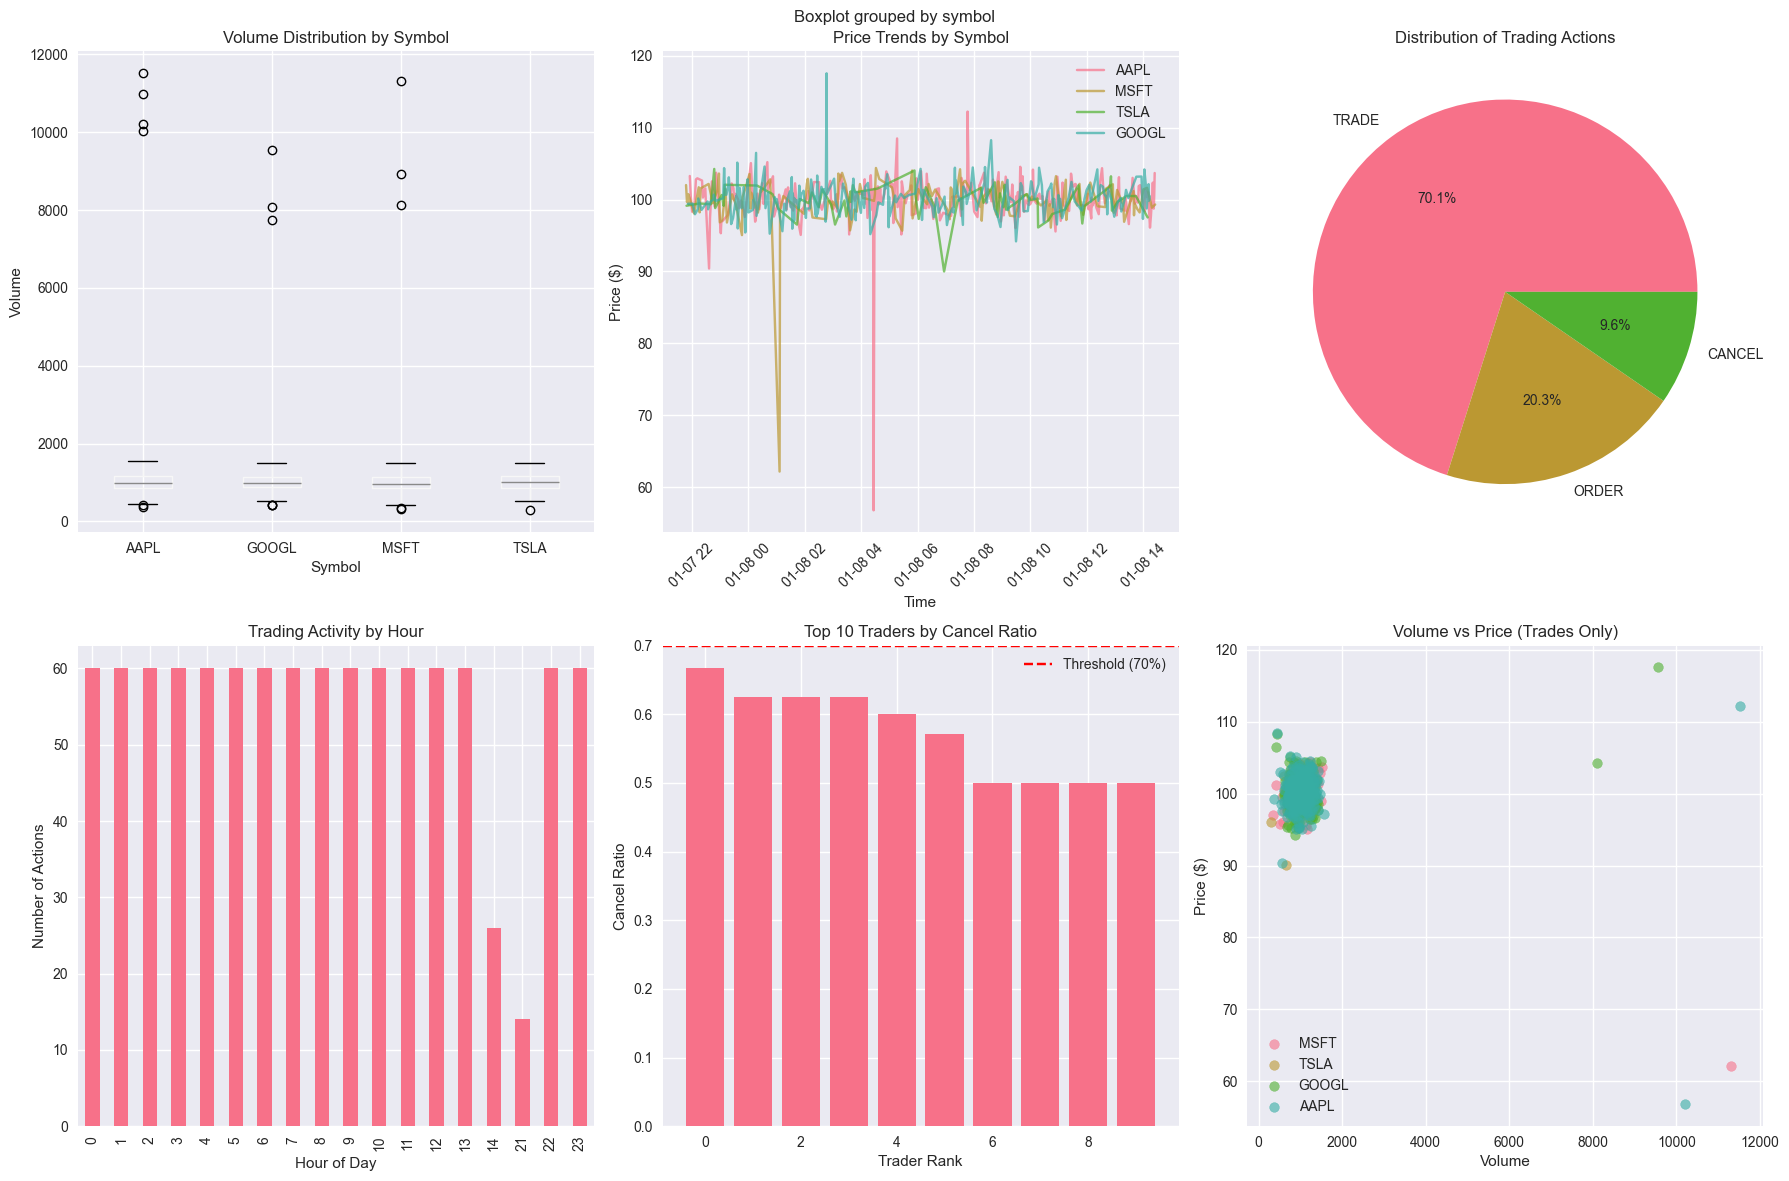

In [51]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Trade Anomaly Detection - Data Analysis Dashboard', fontsize=16, fontweight='bold')

# 1. Volume distribution by symbol
trading_data.boxplot(column='volume', by='symbol', ax=axes[0,0])
axes[0,0].set_title('Volume Distribution by Symbol')
axes[0,0].set_xlabel('Symbol')
axes[0,0].set_ylabel('Volume')

# 2. Price trends over time
for symbol in trading_data['symbol'].unique():
    symbol_data = trading_data[trading_data['symbol'] == symbol]
    trade_data = symbol_data[symbol_data['action'] == 'TRADE'].sort_values('timestamp')
    if len(trade_data) > 1:
        axes[0,1].plot(trade_data['timestamp'], trade_data['price'], label=symbol, alpha=0.7)
axes[0,1].set_title('Price Trends by Symbol')
axes[0,1].set_xlabel('Time')
axes[0,1].set_ylabel('Price ($)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Action distribution
action_counts.plot(kind='pie', ax=axes[0,2], autopct='%1.1f%%')
axes[0,2].set_title('Distribution of Trading Actions')
axes[0,2].set_ylabel('')

# 4. Trading activity by hour
trading_data['hour'] = trading_data['timestamp'].dt.hour
hourly_activity = trading_data.groupby('hour').size()
hourly_activity.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Trading Activity by Hour')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Number of Actions')

# 5. Cancel ratio by trader (top 10)
cancel_ratios = []
for trader in trading_data['trader_id'].unique():
    trader_data = trading_data[trading_data['trader_id'] == trader]
    total_orders = len(trader_data[trader_data['action'].isin(['ORDER', 'CANCEL'])])
    cancels = len(trader_data[trader_data['action'] == 'CANCEL'])
    if total_orders > 0:
        cancel_ratios.append({'trader': trader, 'cancel_ratio': cancels/total_orders})

cancel_df = pd.DataFrame(cancel_ratios).sort_values('cancel_ratio', ascending=False).head(10)
if not cancel_df.empty:
    axes[1,1].bar(range(len(cancel_df)), cancel_df['cancel_ratio'])
    axes[1,1].set_title('Top 10 Traders by Cancel Ratio')
    axes[1,1].set_xlabel('Trader Rank')
    axes[1,1].set_ylabel('Cancel Ratio')
    axes[1,1].axhline(y=0.7, color='r', linestyle='--', label='Threshold (70%)')
    axes[1,1].legend()

# 6. Volume vs Price scatter (trades only)
trade_data_all = trading_data[trading_data['action'] == 'TRADE']
for symbol in trade_data_all['symbol'].unique():
    symbol_trades = trade_data_all[trade_data_all['symbol'] == symbol]
    axes[1,2].scatter(symbol_trades['volume'], symbol_trades['price'], label=symbol, alpha=0.6)
axes[1,2].set_title('Volume vs Price (Trades Only)')
axes[1,2].set_xlabel('Volume')
axes[1,2].set_ylabel('Price ($)')
axes[1,2].legend()

plt.tight_layout()
plt.show()

## Step 6: Generate Detailed Report

Create a comprehensive report of all detected anomalies.

In [52]:
# Generate comprehensive report
report_stats = detector.generate_report()


📋 TRADE ANOMALY DETECTION REPORT
🔍 Total Anomalies Detected: 33
🚨 High Severity: 15
⚠️  Medium Severity: 18

📊 ANOMALY BREAKDOWN BY TYPE:
----------------------------------------
  Potential Wash Trading: 5
  Price Anomaly: 22
  Volume Anomaly: 6

👥 TOP TRADERS WITH ANOMALIES:
----------------------------------------
  T027: 4 anomalies
  T034: 3 anomalies
  T011: 2 anomalies
  T024: 2 anomalies
  T047: 2 anomalies

💹 TOP SYMBOLS WITH ANOMALIES:
----------------------------------------
  AAPL: 14 anomalies
  GOOGL: 11 anomalies
  MSFT: 5 anomalies
  TSLA: 3 anomalies



## Step 7: Detailed Anomaly Analysis

Examine specific types of anomalies in detail.

🔍 DETAILED ANOMALY ANALYSIS

📊 Anomalies by Type and Severity:


severity,HIGH,MEDIUM
type,,
POTENTIAL_WASH_TRADING,5,0
PRICE_ANOMALY,4,18
VOLUME_ANOMALY,6,0



🚨 HIGH SEVERITY ANOMALIES (Most Recent):
------------------------------------------------------------
⚠️  Potential Wash Trading
   Trader: T028 | Symbol: GOOGL
   Time: 2026-01-08 14:07:20
   Details: Alternating pattern: 83.3% over 7 trades

⚠️  Potential Wash Trading
   Trader: T034 | Symbol: AAPL
   Time: 2026-01-08 13:29:20
   Details: Alternating pattern: 71.4% over 8 trades

⚠️  Potential Wash Trading
   Trader: T047 | Symbol: AAPL
   Time: 2026-01-08 12:06:20
   Details: Alternating pattern: 71.4% over 8 trades

⚠️  Volume Anomaly
   Trader: T030 | Symbol: TSLA
   Time: 2026-01-08 10:16:20
   Details: Volume 287 vs avg 987 (Z-score: 3.56)

⚠️  Potential Wash Trading
   Trader: T038 | Symbol: GOOGL
   Time: 2026-01-08 09:11:20
   Details: Alternating pattern: 80.0% over 6 trades



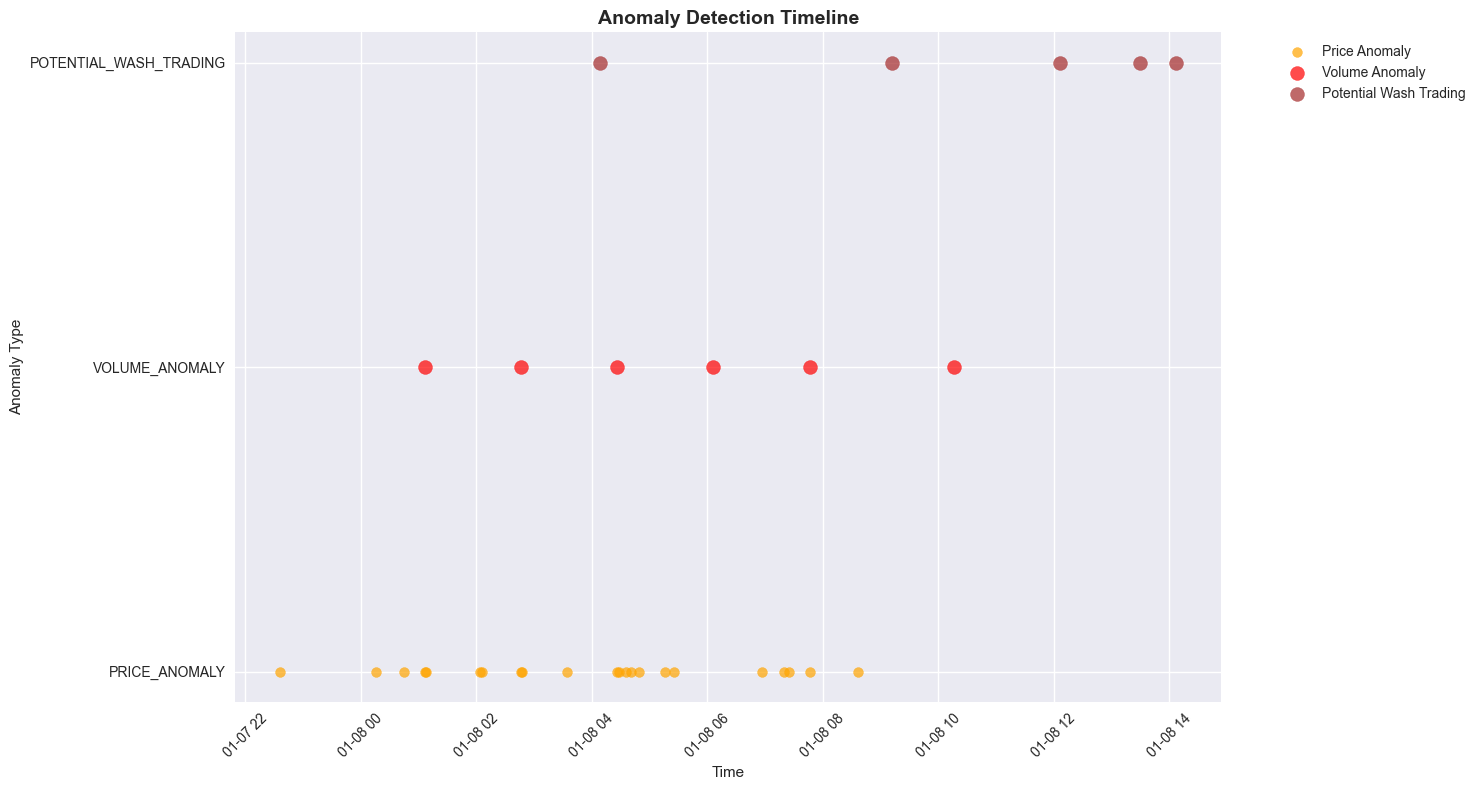

In [53]:
# Convert anomalies to DataFrame for easier analysis
if anomalies:
    anomaly_df = pd.DataFrame(anomalies)
    
    print("🔍 DETAILED ANOMALY ANALYSIS")
    print("=" * 50)
    
    # Show anomalies by type
    print("\n📊 Anomalies by Type and Severity:")
    anomaly_summary = anomaly_df.groupby(['type', 'severity']).size().unstack(fill_value=0)
    display(anomaly_summary)
    
    # Show recent high-severity anomalies
    high_severity = anomaly_df[anomaly_df['severity'] == 'HIGH'].sort_values('timestamp', ascending=False)
    
    if not high_severity.empty:
        print("\n🚨 HIGH SEVERITY ANOMALIES (Most Recent):")
        print("-" * 60)
        for idx, row in high_severity.head(5).iterrows():
            print(f"⚠️  {row['type'].replace('_', ' ').title()}")
            print(f"   Trader: {row['trader_id']} | Symbol: {row['symbol']}")
            print(f"   Time: {row['timestamp'].strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"   Details: {row['details']}")
            print()
    
    # Anomaly timeline visualization
    plt.figure(figsize=(15, 8))
    
    # Create timeline plot
    anomaly_df['timestamp'] = pd.to_datetime(anomaly_df['timestamp'])
    anomaly_df = anomaly_df.sort_values('timestamp')
    
    # Color map for different anomaly types
    type_colors = {
        'VOLUME_ANOMALY': 'red',
        'PRICE_ANOMALY': 'orange', 
        'HIGH_CANCEL_RATIO': 'purple',
        'RAPID_CANCEL_PATTERN': 'magenta',
        'POTENTIAL_WASH_TRADING': 'brown',
        'BURST_TRADING': 'blue'
    }
    
    for anomaly_type in anomaly_df['type'].unique():
        type_data = anomaly_df[anomaly_df['type'] == anomaly_type]
        plt.scatter(type_data['timestamp'], [anomaly_type]*len(type_data), 
                   c=type_colors.get(anomaly_type, 'gray'), 
                   s=100 if type_data['severity'].iloc[0] == 'HIGH' else 50,
                   alpha=0.7, label=anomaly_type.replace('_', ' ').title())
    
    plt.title('Anomaly Detection Timeline', fontsize=14, fontweight='bold')
    plt.xlabel('Time')
    plt.ylabel('Anomaly Type')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
else:
    print("No anomalies detected in the current dataset.")

## Step 8: Cancel Pattern Analysis

Deep dive into cancellation patterns and potential quote stuffing behavior.

❌ CANCELLATION PATTERN ANALYSIS

📊 TOP 10 TRADERS BY CANCEL RATIO:
------------------------------------------------------------


,trader_id,total_actions,orders,cancels,trades,cancel_ratio
13,T032,20,2,4,14,0.666667
27,T027,22,3,5,14,0.625000
39,T026,28,3,5,20,0.625000
20,T019,21,3,5,13,0.625000
33,T035,18,2,3,13,0.600000
29,T029,16,3,4,9,0.571429
10,T034,22,1,1,20,0.500000
34,T010,23,3,3,17,0.500000
19,T049,19,3,3,13,0.500000
18,T012,15,1,1,13,0.500000


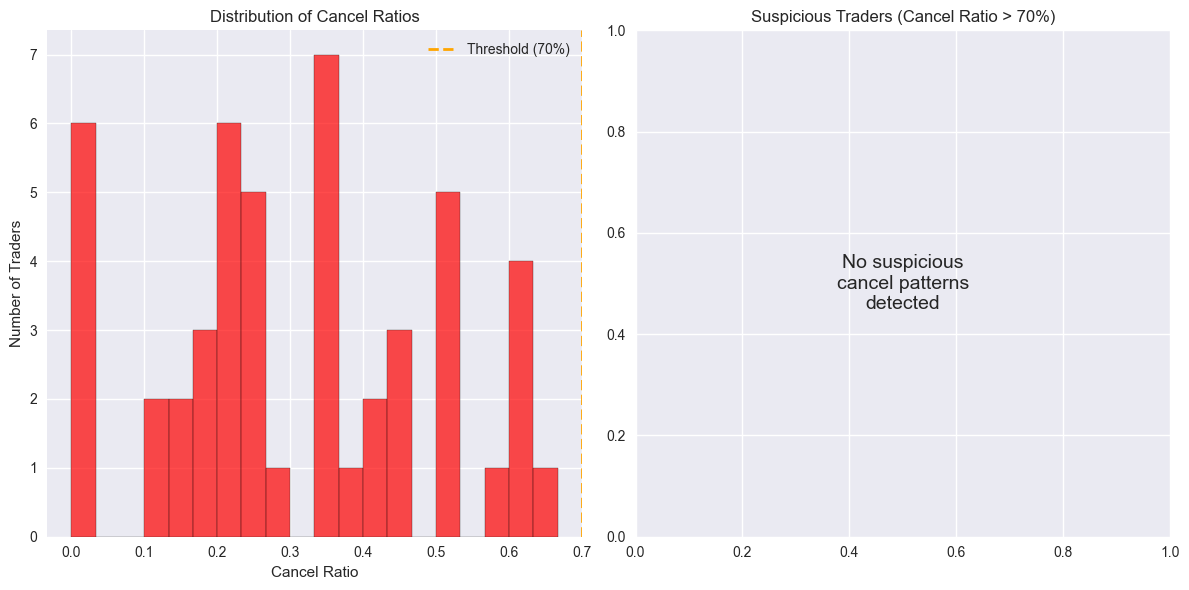

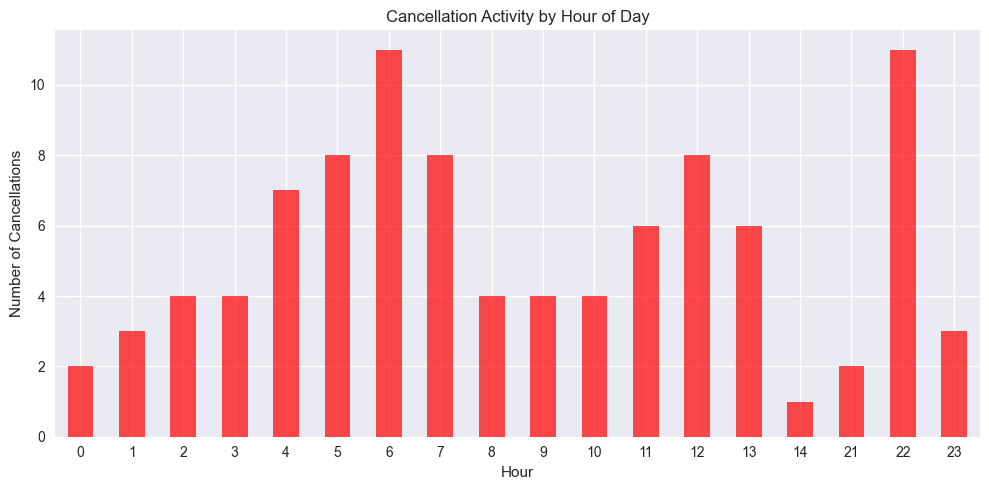

In [54]:
# Analyze cancellation patterns in detail
print("❌ CANCELLATION PATTERN ANALYSIS")
print("=" * 45)

# Calculate cancel ratios for all traders
cancel_analysis = []
for trader in trading_data['trader_id'].unique():
    trader_data = trading_data[trading_data['trader_id'] == trader]
    
    total_actions = len(trader_data)
    orders = len(trader_data[trader_data['action'] == 'ORDER'])
    cancels = len(trader_data[trader_data['action'] == 'CANCEL'])
    trades = len(trader_data[trader_data['action'] == 'TRADE'])
    
    if orders + cancels > 0:
        cancel_ratio = cancels / (orders + cancels)
        cancel_analysis.append({
            'trader_id': trader,
            'total_actions': total_actions,
            'orders': orders,
            'cancels': cancels,
            'trades': trades,
            'cancel_ratio': cancel_ratio
        })

cancel_df = pd.DataFrame(cancel_analysis).sort_values('cancel_ratio', ascending=False)

print("\n📊 TOP 10 TRADERS BY CANCEL RATIO:")
print("-" * 60)
display(cancel_df.head(10))

# Visualize cancel ratio distribution
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(cancel_df['cancel_ratio'], bins=20, alpha=0.7, color='red', edgecolor='black')
plt.axvline(x=0.7, color='orange', linestyle='--', linewidth=2, label='Threshold (70%)')
plt.title('Distribution of Cancel Ratios')
plt.xlabel('Cancel Ratio')
plt.ylabel('Number of Traders')
plt.legend()

plt.subplot(1, 2, 2)
suspicious_traders = cancel_df[cancel_df['cancel_ratio'] > 0.7]
if not suspicious_traders.empty:
    plt.bar(range(len(suspicious_traders)), suspicious_traders['cancel_ratio'], color='red', alpha=0.7)
    plt.title(f'Suspicious Traders (Cancel Ratio > 70%)')
    plt.xlabel('Trader Index')
    plt.ylabel('Cancel Ratio')
    plt.xticks(range(len(suspicious_traders)), 
               [f"{t[:8]}..." for t in suspicious_traders['trader_id']], rotation=45)
else:
    plt.text(0.5, 0.5, 'No suspicious\ncancel patterns\ndetected', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=14)
    plt.title('Suspicious Traders (Cancel Ratio > 70%)')

plt.tight_layout()
plt.show()

# Time-based cancel analysis
cancel_data = trading_data[trading_data['action'] == 'CANCEL'].copy()
if not cancel_data.empty:
    cancel_data['hour'] = cancel_data['timestamp'].dt.hour
    hourly_cancels = cancel_data.groupby('hour').size()
    
    plt.figure(figsize=(10, 5))
    hourly_cancels.plot(kind='bar', color='red', alpha=0.7)
    plt.title('Cancellation Activity by Hour of Day')
    plt.xlabel('Hour')
    plt.ylabel('Number of Cancellations')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Step 9: Export Results and Summary

Save the analysis results and provide actionable recommendations.

In [55]:
# Export results to subfolder with timestamps
print("💾 EXPORTING RESULTS TO SUBFOLDER WITH TIMESTAMPS")
print("=" * 50)

import os
from datetime import datetime

# Create timestamp for filenames
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"🕒 Timestamp: {timestamp}")
print()

# Create 'anomalies' subfolder if it doesn't exist
output_folder = 'anomalies'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"✅ Created folder: {output_folder}")
else:
    print(f"📁 Using existing folder: {output_folder}")

print(f"📂 Save location: {os.path.join(os.getcwd(), output_folder)}")
print()

if anomalies:
    # Export all anomalies to CSV
    anomaly_df = pd.DataFrame(anomalies)
    filename = f'trade_anomalies_{timestamp}.csv'
    anomaly_df.to_csv(os.path.join(output_folder, filename), index=False)
    print(f"✅ Exported: anomalies/{filename} ({len(anomaly_df)} records)")
    
    # Export high severity only
    high_severity = anomaly_df[anomaly_df['severity'] == 'HIGH']
    filename = f'high_severity_anomalies_{timestamp}.csv'
    high_severity.to_csv(os.path.join(output_folder, filename), index=False)
    print(f"✅ Exported: anomalies/{filename} ({len(high_severity)} records)")
    
    # Export cancel-related anomalies
    cancel_anomalies_df = anomaly_df[anomaly_df['type'].str.contains('CANCEL')]
    filename = f'cancel_anomalies_{timestamp}.csv'
    cancel_anomalies_df.to_csv(os.path.join(output_folder, filename), index=False)
    print(f"✅ Exported: anomalies/{filename} ({len(cancel_anomalies_df)} records)")
    
    # Export by anomaly type
    print("\n📊 Exporting by anomaly type:")
    for anomaly_type in anomaly_df['type'].unique():
        type_data = anomaly_df[anomaly_df['type'] == anomaly_type]
        filename = f"{anomaly_type.lower()}_{timestamp}.csv"
        type_data.to_csv(os.path.join(output_folder, filename), index=False)
        print(f"   ✅ {filename} ({len(type_data)} records)")

# Export trading data
filename = f'trading_data_{timestamp}.csv'
trading_data.to_csv(os.path.join(output_folder, filename), index=False)
print(f"\n✅ Exported: anomalies/{filename} ({len(trading_data)} records)")

# Export cancel analysis
if 'cancel_df' in locals() and not cancel_df.empty:
    filename = f'cancel_ratio_analysis_{timestamp}.csv'
    cancel_df.to_csv(os.path.join(output_folder, filename), index=False)
    print(f"✅ Exported: anomalies/{filename} ({len(cancel_df)} traders)")

# List all created files with sizes
print("\n" + "=" * 50)
print("📄 CREATED FILES (This Run):")
print("=" * 50)
import glob
# Get files matching this timestamp
csv_files = glob.glob(os.path.join(output_folder, f'*{timestamp}.csv'))
if csv_files:
    total_size = 0
    for f in sorted(csv_files):
        size = os.path.getsize(f)
        total_size += size
        print(f"   📄 {os.path.basename(f):<50} {size:>8,} bytes")
    print(f"\n   Total size: {total_size:,} bytes")
    print(f"\n📁 Location: {os.path.join(os.getcwd(), output_folder)}")
    
    # Show all timestamped files in folder
    all_csv = glob.glob(os.path.join(output_folder, '*.csv'))
    if len(all_csv) > len(csv_files):
        print(f"\n📚 Total files in anomalies folder: {len(all_csv)} (including previous runs)")
else:
    print("   ⚠️  No files found!")

print("\n" + "=" * 50)
print(f"✅ Export complete at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 50)

💾 EXPORTING RESULTS TO SUBFOLDER WITH TIMESTAMPS
🕒 Timestamp: 20260108_214623

📁 Using existing folder: anomalies
📂 Save location: C:\Users\markj\Documents\coding_projects\Trade_anomalies\anomalies

✅ Exported: anomalies/trade_anomalies_20260108_214623.csv (33 records)
✅ Exported: anomalies/high_severity_anomalies_20260108_214623.csv (15 records)
✅ Exported: anomalies/cancel_anomalies_20260108_214623.csv (0 records)

📊 Exporting by anomaly type:
   ✅ volume_anomaly_20260108_214623.csv (6 records)
   ✅ price_anomaly_20260108_214623.csv (22 records)
   ✅ potential_wash_trading_20260108_214623.csv (5 records)

✅ Exported: anomalies/trading_data_20260108_214623.csv (1000 records)
✅ Exported: anomalies/cancel_ratio_analysis_20260108_214623.csv (49 traders)

📄 CREATED FILES (This Run):
   📄 cancel_anomalies_20260108_214623.csv                     50 bytes
   📄 cancel_ratio_analysis_20260108_214623.csv             1,353 bytes
   📄 high_severity_anomalies_20260108_214623.csv           1,625 by

## Step 10: Summary and Recommendations

Final summary with key findings and actionable recommendations.

In [56]:
print("\n" + "=" * 70)
print("🎯 FINAL SUMMARY AND RECOMMENDATIONS")
print("=" * 70)

if report_stats:
    print(f"\n📊 DETECTION SUMMARY:")
    print(f"   • Total Anomalies: {report_stats['total_anomalies']}")
    print(f"   • High Severity: {report_stats['severity_counts'].get('HIGH', 0)}")
    print(f"   • Medium Severity: {report_stats['severity_counts'].get('MEDIUM', 0)}")
    
    print(f"\n🔍 MOST COMMON ANOMALY TYPES:")
    sorted_types = sorted(report_stats['anomaly_types'].items(), key=lambda x: x[1], reverse=True)
    for anomaly_type, count in sorted_types[:3]:
        print(f"   • {anomaly_type.replace('_', ' ').title()}: {count}")
    
    if report_stats['top_traders']:
        print(f"\n👥 TRADERS REQUIRING ATTENTION:")
        for trader, count in list(report_stats['top_traders'].items())[:3]:
            print(f"   • {trader}: {count} anomalies")

print("\n💡 KEY RECOMMENDATIONS:")
print("-" * 40)

recommendations = [
    "🚨 IMMEDIATE ACTIONS:",
    "   • Review all HIGH severity anomalies within 24 hours",
    "   • Investigate traders with cancel ratios > 70%",
    "   • Examine potential wash trading patterns",
    "",
    "⚙️  SYSTEM IMPROVEMENTS:",
    "   • Implement real-time anomaly detection",
    "   • Set up automated alerts for high-risk patterns",
    "   • Regular threshold calibration based on market conditions",
    "",
    "📋 COMPLIANCE MEASURES:",
    "   • Document all anomaly investigations",
    "   • Consider regulatory reporting for confirmed violations",
    "   • Review and update trading policies",
    "",
    "📊 ONGOING MONITORING:",
    "   • Daily anomaly detection runs",
    "   • Weekly trend analysis and reporting",
    "   • Monthly threshold optimization"
]

for rec in recommendations:
    print(rec)

print("\n" + "=" * 70)
print("✅ TRADE ANOMALY DETECTION ANALYSIS COMPLETE")
print("=" * 70)
print("\n📝 This notebook provided comprehensive analysis of:")
print("   • Volume and price anomalies")
print("   • Cancellation abuse patterns")
print("   • Potential wash trading")
print("   • Timing irregularities")
print("   • Market manipulation indicators")
print("\n🔧 The detection system is fully customizable and can be")
print("   integrated with live trading data for real-time monitoring.")


🎯 FINAL SUMMARY AND RECOMMENDATIONS

📊 DETECTION SUMMARY:
   • Total Anomalies: 33
   • High Severity: 15
   • Medium Severity: 18

🔍 MOST COMMON ANOMALY TYPES:
   • Price Anomaly: 22
   • Volume Anomaly: 6
   • Potential Wash Trading: 5

👥 TRADERS REQUIRING ATTENTION:
   • T027: 4 anomalies
   • T034: 3 anomalies
   • T011: 2 anomalies

💡 KEY RECOMMENDATIONS:
----------------------------------------
🚨 IMMEDIATE ACTIONS:
   • Review all HIGH severity anomalies within 24 hours
   • Investigate traders with cancel ratios > 70%
   • Examine potential wash trading patterns

⚙️  SYSTEM IMPROVEMENTS:
   • Implement real-time anomaly detection
   • Set up automated alerts for high-risk patterns
   • Regular threshold calibration based on market conditions

📋 COMPLIANCE MEASURES:
   • Document all anomaly investigations
   • Consider regulatory reporting for confirmed violations
   • Review and update trading policies

📊 ONGOING MONITORING:
   • Daily anomaly detection runs
   • Weekly trend 

## Additional Notes

### How to Use This Notebook:

1. **Run all cells sequentially** to execute the complete analysis
2. **Modify thresholds** in Step 2 to adjust sensitivity
3. **Load your own data** by replacing the sample data generation
4. **Export results** using the provided code snippets

### Customization Options:

- **Z-Score Threshold**: Lower values = more sensitive detection
- **Volume Multiplier**: Adjust based on market volatility
- **Cancel Ratio Threshold**: Set based on regulatory requirements

### Integration with Live Data:

Replace the `load_sample_data()` method with your data loading logic:

```python
# Example: Load from database
import sqlalchemy
engine = sqlalchemy.create_engine('your_connection_string')
df = pd.read_sql('SELECT * FROM trades WHERE date >= CURRENT_DATE', engine)

# Run detection
anomalies, data = detector.run_detection(df)
```

### Performance Considerations:

- For large datasets (>100K records), consider processing in chunks
- Use database-level filtering to reduce data loading time
- Implement parallel processing for multiple symbols

---

*This notebook provides a comprehensive framework for trade anomaly detection. Adapt the parameters and methods based on your specific requirements and regulatory environment.*